In [1]:
import pandas as pd
import os

In [2]:
df = pd.read_csv('data/df_train_raw_c.csv')

In [3]:
df['plate'] = df.filepath.apply(lambda x: '_'.join(os.path.basename(x).split('_')[:-1]))

In [4]:
df.filepath.iloc[5339]

'data/train/c/wmv_for_c/2019_beauvechain_w27_1-15_4183x6278_33872.png'

In [20]:
df.plate.iloc[5339]

'2019_beauvechain_w27_1-15_4183x6278'

In [12]:
# Check for plates with 2019_brainelalleud_w31 in the name
df_bright = df[df.plate.str.contains('2019_brainelalleud_w31')]
df_medium = df[df.plate.str.contains('2019_brainelalleud_w37_A')]
df_dark = df[df.plate.str.contains('2020_herent_w31_1-60')]

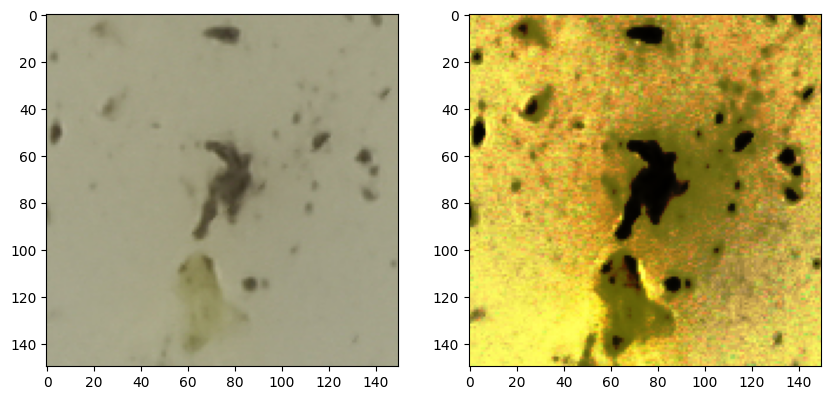

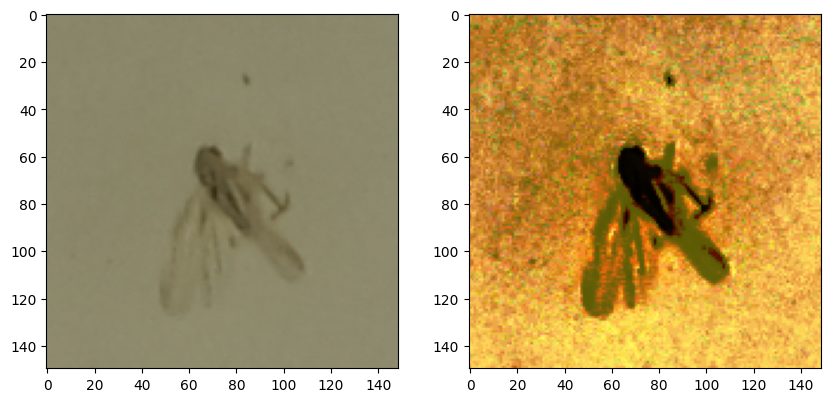

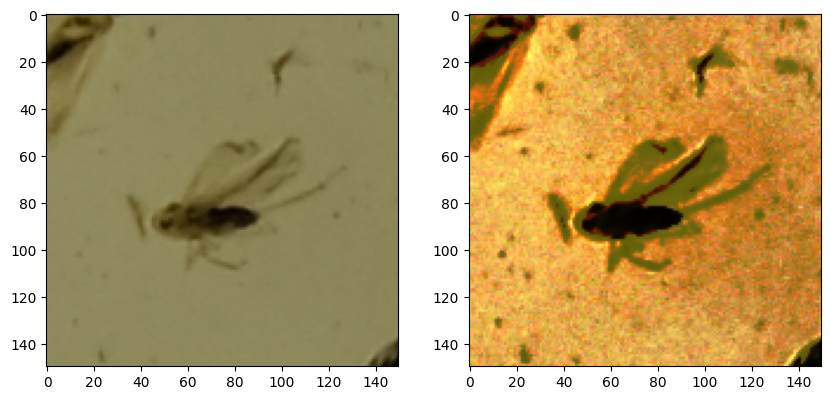

In [15]:
# Perform histogram equalization one image using skimage
from skimage import io
from skimage import exposure
import matplotlib.pyplot as plt

def equalize_hist(img_path):
    img = io.imread(img_path)
    img_eq = exposure.equalize_hist(img)

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img, cmap='gray')
    ax[1].imshow(img_eq, cmap='gray')
    plt.show()

equalize_hist(df_bright.filepath.iloc[1])
equalize_hist(df_medium.filepath.iloc[0])
equalize_hist(df_dark.filepath.iloc[1])


In [6]:
# plot images with their plate name
# import matplotlib.pyplot as plt
# import cv2

# def plot_images(df, n_images=len(df)):
#     plt.figure(figsize=(20, 10))
#     for i in range(n_images):
#         # plt.subplot(1, n_images, i+1)
#         img = cv2.imread(df.filepath.iloc[i])
#         img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#         plt.imshow(img)
#         plt.title(df.plate.iloc[i])
#         plt.axis('off')
#         plt.show()

# plot_images(df)

In [19]:
import torch
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from mnist_dataset import CustomBinaryInsectDF


transform = T.Compose([
    T.Resize((150, 150)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), 
])

dataset = CustomBinaryInsectDF(df, transform = transform, seed=1265)
dataloader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=0)


In [20]:
# Initialize variables
mean = torch.zeros(3)  # For RGB images
std = torch.zeros(3)
num_samples = 0

for images, labels, _, measurement_noise, label_noise, _ in dataloader:
    batch_samples = images.size(0)  # Batch size
    images = images.view(batch_samples, 3, -1)  # Flatten height and width
    mean += images.mean(dim=[0, 2]) * batch_samples
    std += images.std(dim=[0, 2]) * batch_samples
    num_samples += batch_samples

# Final mean and std
mean /= num_samples
std /= num_samples

print(f"Mean: {mean.tolist()}, Std: {std.tolist()}")


Mean: [0.5411064028739929, 0.5189061760902405, 0.3637252449989319], Std: [0.06006000563502312, 0.0644952654838562, 0.0696176290512085]


In [ ]:
normalize_transform = T.Normalize(mean=mean.tolist(), std=std.tolist())

transform = T.Compose([
    T.ToTensor(),
    normalize_transform
])


In [31]:
import os
import torch
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt

# Define your dataset path and temporary save path
save_path = "zztemp_images_standardized"
os.makedirs(save_path, exist_ok=True)

# Load dataset with basic transforms
transform = T.Compose([
    T.Resize((150, 150)),
    T.ToTensor(),
])

dataset = CustomBinaryInsectDF(df, transform = transform, seed=1265)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

# Calculate mean and std
mean = torch.zeros(3)
std = torch.zeros(3)
num_samples = 0

for images, labels, _, measurement_noise, label_noise, _  in dataloader:
    images = images.view(1, 3, -1)  # Flatten height & width
    mean += images.mean(dim=[0, 2])
    std += images.std(dim=[0, 2])
    num_samples += 1

mean /= num_samples
std /= num_samples

print(f"Calculated Mean: {mean.tolist()}, Std: {std.tolist()}")

# Define normalization transform
normalize_transform = T.Compose([
    #T.Normalize(mean=mean.tolist(), std=std.tolist())
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Save some images before and after normalization
for i, (image, labels, _, measurement_noise, label_noise, _ ) in enumerate(dataloader):
    # Convert tensor to PIL for saving
    original_img = T.ToPILImage()(image.squeeze(0))
    original_img.save(os.path.join(save_path, f"{i}_orig.png"))

    # Apply normalization
    normalized_img = normalize_transform(image)
    normalized_img = torch.clamp((normalized_img * std[:, None, None] + mean[:, None, None]), 0, 1)  # Undo normalization for visualization
    normalized_img = T.ToPILImage()(normalized_img.squeeze(0))
    normalized_img.save(os.path.join(save_path, f"{i}_norm.png"))

print(f"Images saved in: {save_path}")


Calculated Mean: [0.5241954326629639, 0.5048666000366211, 0.34402573108673096], Std: [0.0885615199804306, 0.09013594686985016, 0.07278003543615341]


KeyboardInterrupt: 

In [30]:
# Use skimage image matching to make images have the hisogram of the reference image
from skimage import exposure, io
import numpy as np

def match_histograms(image, reference):
    return exposure.match_histograms(image, reference, channel_axis=-1)


ref = io.imread("data/train_dif_colour/wmv/wmv_trash/2019_beauvechain_w27_C_4183x6278_35568.png")

# Load images
filepaths = df.filepath.to_list()

# Match histograms, opening images with skimage
matched_images = [match_histograms(io.imread(fp.replace('train', 'train_dif_colour')), ref) for fp in filepaths]


# Save images
os.makedirs("histogram_matched_images", exist_ok=True)
for i, img in enumerate(matched_images):
    io.imsave(f"histogram_matched_images/{i}_matched.png", img)
    # copy original images from filepaths to the same folder
    img_orig = io.imread(filepaths[i].replace('train', 'train_dif_colour'))
    io.imsave(f"histogram_matched_images/{i}_orig.png", img_orig)


/tmp/ipykernel_969081/1833489389.py:21: UserWarning: histogram_matched_images/0_matched.png is a low contrast image
  io.imsave(f"histogram_matched_images/{i}_matched.png", img)
/tmp/ipykernel_969081/1833489389.py:21: UserWarning: histogram_matched_images/1_matched.png is a low contrast image
  io.imsave(f"histogram_matched_images/{i}_matched.png", img)
/tmp/ipykernel_969081/1833489389.py:21: UserWarning: histogram_matched_images/2_matched.png is a low contrast image
  io.imsave(f"histogram_matched_images/{i}_matched.png", img)
/tmp/ipykernel_969081/1833489389.py:21: UserWarning: histogram_matched_images/3_matched.png is a low contrast image
  io.imsave(f"histogram_matched_images/{i}_matched.png", img)
/tmp/ipykernel_969081/1833489389.py:21: UserWarning: histogram_matched_images/4_matched.png is a low contrast image
  io.imsave(f"histogram_matched_images/{i}_matched.png", img)
/tmp/ipykernel_969081/1833489389.py:21: UserWarning: histogram_matched_images/5_matched.png is a low contrast 

KeyboardInterrupt: 